# 10 - Simpler VAE with Few Spectral Orders

In this notebook, I train a **simplified 1D VAE** model to compress spectra of **AU Mic** using **only 3 spectral orders** (25, 46, 47). This is based on the hypothesis that:
- These orders contain key chromospheric activity indicators (e.g. H-alpha and Ca II triplet)
- A shallower model is better suited for small datasets (here: 95 spectra)

**Goals:**
- Reduce model complexity to improve generalization
- Use some informative orders instead of the full range
- Visualize the latent space with PCA/t-SNE/UMAP
- Identify periodic signals via Lomb-Scargle analysis

In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPUs detected:", tf.config.list_physical_devices('GPU'))

2025-06-19 19:29:35.273685: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-19 19:29:35.401212: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-19 19:29:35.401250: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-19 19:29:35.420511: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-19 19:29:35.458684: I tensorflow/core/platform/cpu_feature_guar

TensorFlow version: 2.15.0
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2025-06-19 19:29:37.328311: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-06-19 19:29:37.402595: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-06-19 19:29:37.407417: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

### 1. Setup and Imports

Als erstes mal das mit den Plots korrigieren. dass die richtig gespeichert werden.

---

Schritt 3:

- normalisierung, dass alle Spektren uebereinanderliegen - alle sollen den gleichen mean haben (von jedem den mean abziehen und dann hat man die Standardeviation von allen)

---

Schritt 2: 

AUF SELBES WELLENLAENGENGRID!

- ist der abstand zwischen den Wellenlaengen immer der gleiche/Revolution gleich?

- resample/spline fit, dass sie punkte alle auf der selben Wellenlaenge liegen

- ich will dass ich fuer alle genau die gleichen Wellenlaengen reingeben. - Grid bastelen


---

Schritt 1:

- alle spektren um die RV verschieben, sodass sie alle gleich stehen - dann koennte man nur die assymetrien sehen (das ist nur ein Test) - wenn man sie verschiebt oder wenn man sie nicht verschiebt, dann muesste man immer noch eine correlation mit dem latent Space un RV sehen.

- and den Raenderen abschneiden, sodass die alle gleich sind

- alle Lambdas mit der RV verschieben (entweder RV shift/ oder nicht RV shift)

Bei allem schauen, was am besten funktioniert!

---

wie haengen die Latent space dimensionen mit den Indikatoren ab:
RV/ Full Width - Half Maximum / Contrast /SNR 
- alles mit dem UMAP anschauen


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.interpolate import interp1d
import os
import random
from astropy.io import fits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from astropy.timeseries import LombScargle
import umap
import json

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Input, Dense, Lambda, Conv1D, Flatten, Reshape, UpSampling1D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K
from keras.saving import register_keras_serializable

/home/ice/.cache/pypoetry/virtualenvs/exoplanet-autoencoder-LTlp-vC0-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setting up an internal seed:

In [3]:
np.random.seed(42)
tf.random.set_seed(42)

seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

tf.config.experimental.enable_op_determinism()

### 2. Data Loading and Preprocessing

In [4]:
VALID_ORDERS = list(range(17, 39)) # 17-39

In [5]:
with open("../../aumicAE/data/carvis_visA/vis_a_files.txt", "r") as f:
    vis_a_files = ["../../aumicAE/" + line.strip().lstrip("../") for line in f if line.strip()]

meta = pd.read_csv("../outputs/aligned_metadata/aligned_metadata.csv")
meta = meta.sort_values("BJD").reset_index(drop=True)

In [6]:
with fits.open(vis_a_files[0]) as hdul:
    wave_data = hdul["WAVE"].data

for o in VALID_ORDERS:
    w = wave_data[o]
    print(f"Order {o}: {w[0]:.1f} – {w[-1]:.1f} Å")

Order 17: 6001.2 – 6105.8 Å
Order 18: 6061.2 – 6166.8 Å
Order 19: 6122.5 – 6229.1 Å
Order 20: 6184.9 – 6292.7 Å
Order 21: 6248.7 – 6357.5 Å
Order 22: 6313.8 – 6423.7 Å
Order 23: 6380.3 – 6491.3 Å
Order 24: 6448.2 – 6560.4 Å
Order 25: 6517.5 – 6630.9 Å
Order 26: 6588.4 – 6703.0 Å
Order 27: 6660.8 – 6776.6 Å
Order 28: 6734.8 – 6851.9 Å
Order 29: 6810.4 – 6928.9 Å
Order 30: 6887.8 – 7007.6 Å
Order 31: 6967.0 – 7088.1 Å
Order 32: 7048.0 – 7170.5 Å
Order 33: 7131.0 – 7254.9 Å
Order 34: 7215.9 – 7341.2 Å
Order 35: 7302.8 – 7429.7 Å
Order 36: 7391.9 – 7520.2 Å
Order 37: 7483.1 – 7613.1 Å
Order 38: 7576.7 – 7708.2 Å


In [7]:
def stack_orders(file_path, orders=VALID_ORDERS):
    with fits.open(file_path) as hdul:
        flux = hdul["SPEC"].data
        cont = hdul["CONT"].data
        spec = flux / np.clip(cont, 1e-3, np.inf)
        spec = np.nan_to_num(spec, nan=0.0, posinf=0.0, neginf=0.0)
        return np.hstack([spec[o] for o in orders])

X = np.array([stack_orders(f) for f in vis_a_files])
assert len(meta) == len(X)

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Input data shape:", X_scaled.shape)

Input data shape: (95, 90112)


### 3. VAE Definition

**Define MC-Dropout:**

In [9]:
@register_keras_serializable()
class MCDropout(Layer):
    def __init__(self, rate, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=None):
        return tf.nn.dropout(inputs, rate=self.rate)

#### **Sampling**

In a standard autoencoder, the encoder outputs a fixed latent vector.

But in a VAE, the encoder instead outputs parameters of a probability distribution (usually a multivariate normal):

$z_{\text{mean}}$ = the mean vector $\mu$

$z_{\text{log\_sigma}}$ = the log-variance $\log \sigma^2$

We want to sample a point from this distribution:

$z = \mu + \omega \times \epsilon∼N(0,1)$

where $\epsilon$ is independent of $\mu$ and $\sigma$, we make the sampling differentiable, enabling training via gradient descent.

In [10]:
class SimpleConvVAE1D:
    def __init__(self, input_dim, latent_dim=3, actfn="relu", dropout_rate=0.1, beta=1e-3):
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.actfn = actfn
        #self.dropout_rate = dropout_rate
        self.beta = beta

    def sampling(self, args):
        z_mean, z_log_sigma = args
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(z_log_sigma) * epsilon

    def model_tf(self):
        # Encoder
        inputs = Input(shape=(self.input_dim,))
        x = Reshape((self.input_dim, 1))(inputs) # Reshape to 3D for Conv1D, we cannot use 2D Conv1D

        x = Conv1D(32, 5, activation=self.actfn, padding="same")(x)
        #x = BatchNormalization()(x)
        #x = MCDropout(self.dropout_rate)(x)
        
        x = Conv1D(64, 5, activation=self.actfn, padding="same")(x)
        #x = BatchNormalization()(x)
        #x = MCDropout(self.dropout_rate)(x)

        x = Flatten()(x)
        x = Dense(128, activation=self.actfn)(x)

        z_mean = Dense(self.latent_dim)(x)
        z_log_sigma = Dense(self.latent_dim)(x)
        z = Lambda(self.sampling)([z_mean, z_log_sigma])

        encoder = Model(inputs, [z_mean, z_log_sigma, z], name="encoder")

        # Decoder
        latent_inputs = Input(shape=(self.latent_dim,), name="z_sampling")
        x = Dense(self.input_dim, activation=self.actfn)(latent_inputs)
        x = Reshape((self.input_dim, 1))(x)

        x = Conv1D(64, 5, activation=self.actfn, padding="same")(x)
        #x = BatchNormalization()(x)
        #x = MCDropout(self.dropout_rate)(x)

        x = Conv1D(32, 5, activation=self.actfn, padding="same")(x)
        #x = BatchNormalization()(x)
        #x = MCDropout(self.dropout_rate)(x)
        
        x = Conv1D(1, 3, activation="linear", padding="same")(x)
        outputs = Reshape((self.input_dim,))(x)

        decoder = Model(latent_inputs, outputs, name="decoder")

        # VAE model
        z_mean, z_log_sigma, z = encoder(inputs)
        reconstructed = decoder(z)
        vae = Model(inputs, reconstructed, name="vae")

        # KL divergence loss
        kl_loss = -0.5 * tf.reduce_mean(1 + z_log_sigma - tf.square(z_mean) - tf.exp(z_log_sigma))
        recon_loss = tf.reduce_mean(tf.square(inputs - reconstructed))
        vae.add_loss(self.beta * kl_loss + recon_loss)

        return vae, encoder, decoder

---

Without errors:

In [11]:
class SimpleConvVAE1D:
    def __init__(self, input_dim, latent_dim=3, actfn="relu", beta=tf.Variable(0.0, trainable=False), dropout_rate=0.1):
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.actfn = actfn
        self.beta = beta  # Important: tf.Variable
        self.dropout_rate = dropout_rate

    def sampling(self, args):
        z_mean, z_log_sigma = args
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(z_log_sigma) * epsilon

    def model_tf(self):
        ###### Encoder ######
        inputs = Input(shape=(self.input_dim,))
        x = Reshape((self.input_dim, 1))(inputs) # Reshape to 3D for Conv1D, we cannot use 2D Conv1D
        x = Conv1D(32, 5, activation=self.actfn, padding="same")(x)
        x = Conv1D(64, 5, activation=self.actfn, padding="same")(x)
        x = Flatten()(x)

        z_mean = Dense(self.latent_dim)(x)
        z_log_sigma = Dense(self.latent_dim)(x)
        # Clip the sigma to avoid numerical issues:
        z_mean_clipped = tf.clip_by_value(z_mean, -10.0, 10.0)
        z_log_sigma_clipped = tf.clip_by_value(z_log_sigma, -10.0, 10.0)

        z = Lambda(self.sampling)([z_mean_clipped, z_log_sigma_clipped])

        encoder = Model(inputs, [z_mean, z_log_sigma, z], name="encoder")

        ###### Decoder ######
        latent_inputs = Input(shape=(self.latent_dim,))
        x = Dense(self.input_dim, activation=self.actfn)(latent_inputs)
        x = Reshape((self.input_dim, 1))(x)
        x = Conv1D(64, 5, activation=self.actfn, padding="same")(x)
        x = MCDropout(self.dropout_rate)(x)  # Use MCDropout for regularization
        x = Conv1D(32, 5, activation=self.actfn, padding="same")(x)
        x = Conv1D(1, 3, activation="linear", padding="same")(x)
        outputs = Reshape((self.input_dim,))(x)

        decoder = Model(latent_inputs, outputs, name="decoder")

        z_mean, z_log_sigma, z = encoder(inputs)
        reconstructed = decoder(z)

        vae = Model(inputs, reconstructed, name="vae")

        kl_loss = -0.5 * tf.reduce_mean(1 + z_log_sigma - tf.square(z_mean) - tf.exp(z_log_sigma))
        recon_loss = tf.reduce_mean(tf.square(inputs - reconstructed))

        # beta is a tf.Variable that will be updated dynamically
        vae.add_loss(self.beta * kl_loss + recon_loss)
        return vae, encoder, decoder

2025-06-19 19:29:41.993778: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-06-19 19:29:41.998053: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-06-19 19:29:42.000448: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

**KL Annealing Callback:**

Linearly increase beta from 0 to max_beta over n_epochs.

In a **Variational Autoencoder (VAE)**, **β (beta)** is a hyperparameter that scales the KL divergence term in the loss function:

$$
\mathcal{L} = \text{Reconstruction Loss} + \beta \cdot \text{KL Divergence}
$$

Start with β = 0 and **slowly increase it** during training. This lets the model:

* First focus on learning accurate reconstructions.
* Then gradually learn a smooth and regular latent space.

This annealing helps prevent issues like:

* KL vanishing
* Posterior collapse (where all latent codes are identical)
* NaNs from unstable gradients at the start


In [12]:
class BetaAnnealingCallback(tf.keras.callbacks.Callback):
    def __init__(self, beta_variable, max_beta=1e-3, n_epochs=100):
        self.beta_variable = beta_variable
        self.max_beta = max_beta
        self.n_epochs = n_epochs

    def on_epoch_begin(self, epoch, logs=None):
        new_beta = min(self.max_beta, self.max_beta * (epoch / self.n_epochs))
        self.beta_variable.assign(new_beta)
        print(f"Epoch {epoch+1}: beta = {new_beta:.6f}")

**Hyper Parameter Definitions:**

Compile:

In [13]:
LATENT_DIM = 8
ACTFN = "relu" #"tanh" 
LEARNING_RATE = 1e-5
BATCH_SIZE = 8
PATIENCE = 20 # currently early stopping not available since we reduce the learning rate manually
EPOCHS = 100
BETA_VAR = tf.Variable(1e-6, trainable=False) # initialize Beta slightly above 0 to avoid zero gradients at the start
BETA_MAX = 1e-3
DROPOUT = 0
MODEL_VERSION = "0"

**Define and Compile VAE model:**

In [14]:
vae_model = SimpleConvVAE1D(
    input_dim=X.shape[1],
    latent_dim=LATENT_DIM,
    actfn=ACTFN,
    beta=BETA_VAR,
    dropout_rate=DROPOUT
)

vae, encoder, decoder = vae_model.model_tf()
vae.compile(optimizer=Adam(LEARNING_RATE))

callbacks = [
    BetaAnnealingCallback(BETA_VAR, max_beta=BETA_MAX, n_epochs=50),
    ReduceLROnPlateau(monitor='loss', factor=0.2, patience=PATIENCE)
]

### 4. Training 

Clear any previous Keras sessions to avoid clutter:

In [15]:
tf.keras.backend.clear_session()

Here we dit the model:

In [16]:
history = vae.fit(
    X_scaled, X_scaled,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1: beta = 0.000000
Epoch 1/100


2025-06-19 19:29:43.371746: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-06-19 19:29:44.214690: I external/local_xla/xla/service/service.cc:168] XLA service 0x7dba981b1d00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-06-19 19:29:44.214751: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-06-19 19:29:44.221297: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1750354184.282412   10157 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


12/12 [==============================] - 4s 113ms/step - loss: 5.8525 - lr: 1.0000e-05
Epoch 2: beta = 0.000020
Epoch 2/100
12/12 [==============================] - 1s 107ms/step - loss: 0.9755 - lr: 1.0000e-05
Epoch 3: beta = 0.000040
Epoch 3/100
12/12 [==============================] - 1s 107ms/step - loss: 0.9878 - lr: 1.0000e-05
Epoch 4: beta = 0.000060
Epoch 4/100
12/12 [==============================] - 1s 107ms/step - loss: 0.9865 - lr: 1.0000e-05
Epoch 5: beta = 0.000080
Epoch 5/100
12/12 [==============================] - 1s 106ms/step - loss: 0.9809 - lr: 1.0000e-05
Epoch 6: beta = 0.000100
Epoch 6/100
12/12 [==============================] - 1s 107ms/step - loss: 0.9882 - lr: 1.0000e-05
Epoch 7: beta = 0.000120
Epoch 7/100
12/12 [==============================] - 1s 107ms/step - loss: 0.9839 - lr: 1.0000e-05
Epoch 8: beta = 0.000140
Epoch 8/100
12/12 [==============================] - 1s 107ms/step - loss: 0.9836 - lr: 1.0000e-05
Epoch 9: beta = 0.000160
Epoch 9/100
12/12 [=

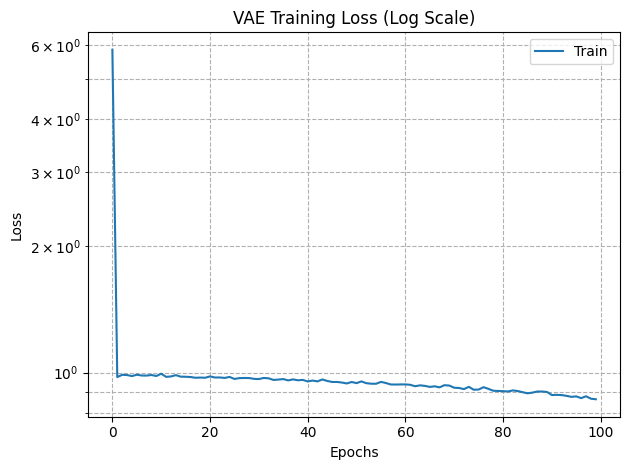

In [26]:
plt.plot(history.history['loss'], label='Train')
plt.title("VAE Training Loss (Log Scale)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.yscale("log")
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.legend()
save_path = f"outputs/models/vae_base/v_{MODEL_VERSION}/plots/loss/training_loss.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()

### 5. Latent Space Visualization

In [18]:
z_mean, _, _ = encoder.predict(X_scaled)
x_pred = decoder.predict(z_mean)

3/3 [==============================] - 0s 56ms/step


#### **PCA**

Captures: Linear variance

Preserves: Global structure

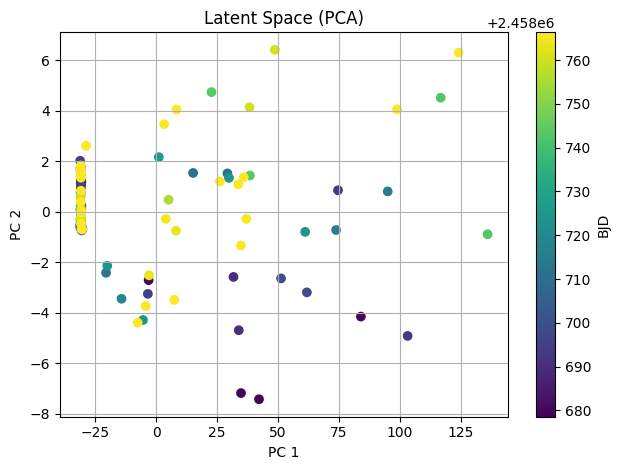

In [27]:
pca = PCA(n_components=2)
latent_pca = pca.fit_transform(z_mean)

plt.scatter(latent_pca[:, 0], latent_pca[:, 1], c=meta["BJD"], cmap="viridis")
plt.colorbar(label="BJD")
plt.title("Latent Space (PCA)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

#### **t-SNE**

Captures: Non-linear clusters.	

Preserves: Local neighborhood

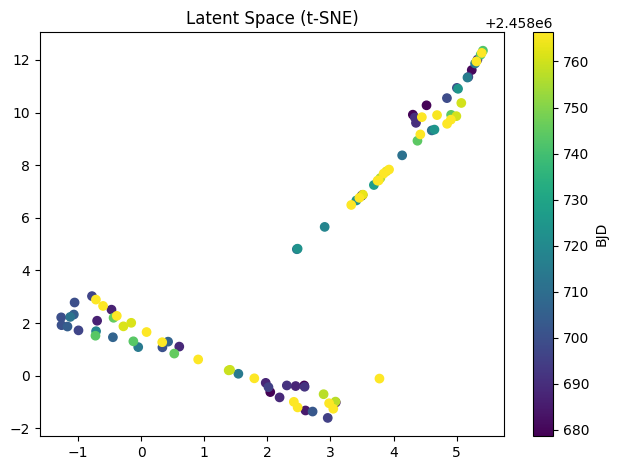

In [28]:
tsne = TSNE(n_components=2, perplexity=min(30, len(z_mean) // 2))
latent_tsne = tsne.fit_transform(z_mean)
plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=meta["BJD"], cmap="viridis")
plt.colorbar(label="BJD")
plt.title("Latent Space (t-SNE)")
plt.tight_layout()
plt.show()
plt.close()

#### **UMAP**

Captures: Non-linear clusters + global topology

Preserves: Local & some global

In [20]:
meta.head()

,BJD,RV,FWHM,CONTRAST,BIS,RV_err,FWHM_err,CONTRAST_err,BIS_err,SNR_0,...,SNR_51,SNR_52,SNR_53,SNR_54,SNR_55,SNR_56,SNR_57,SNR_58,SNR_59,HALPHA
0,2.458679e+06,-5.328574,12.673912,10.063694,0.306980,0.012692,0.077585,0.048857,0.034974,0.81934,...,51.934,48.400,27.051,23.217,17.207,3.3272,0.68643,0.66007,0.59854,2.69504
1,2.458679e+06,-5.328574,12.673912,10.063694,0.306980,0.012692,0.077585,0.048857,0.034974,0.72417,...,58.482,54.748,31.184,27.201,20.439,4.0012,0.72475,0.66359,0.65050,2.70468
2,2.458680e+06,-5.008305,12.220235,7.271535,-0.081408,0.009027,0.064395,0.030526,0.022669,2.04820,...,78.744,72.605,37.593,33.164,25.062,4.8941,0.71734,0.63908,0.63569,3.53532
3,2.458680e+06,-5.008305,12.220235,7.271535,-0.081408,0.009027,0.064395,0.030526,0.022669,2.07890,...,80.320,74.110,38.781,34.135,25.362,5.0982,0.68355,0.59042,0.57342,3.70245
4,2.458681e+06,-5.048751,12.359634,9.902224,-0.103738,0.007096,0.055803,0.035579,0.018071,0.69870,...,88.365,81.226,38.778,36.505,30.174,7.1670,0.83053,0.68831,0.57930,3.08575


/home/ice/.cache/pypoetry/virtualenvs/exoplanet-autoencoder-LTlp-vC0-py3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


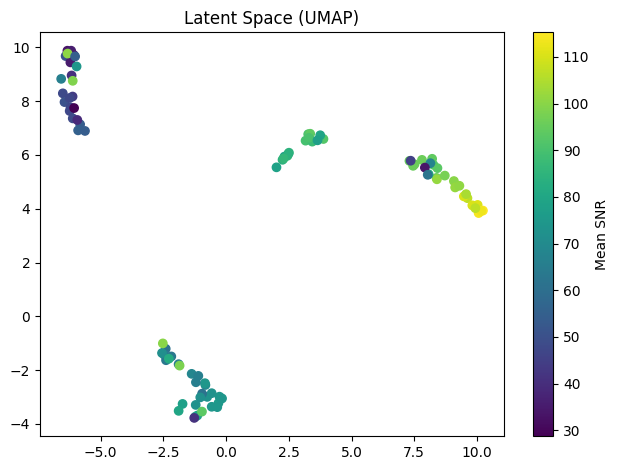

In [29]:
umap_reducer = umap.UMAP(n_components=2)
latent_umap = umap_reducer.fit_transform(z_mean)

snr_cols = [f"SNR_{o}" for o in VALID_ORDERS]
meta["SNR_mean"] = meta[snr_cols].mean(axis=1)

plt.scatter(latent_umap[:, 0], latent_umap[:, 1], c=meta["SNR_mean"], cmap="viridis")
plt.colorbar(label="Mean SNR")
plt.title("Latent Space (UMAP)")
plt.tight_layout()

save_path = f"outputs/models/vae_base/v_{MODEL_VERSION}/plots/UMAP/SNR_mean.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=150)

plt.show()
plt.close()

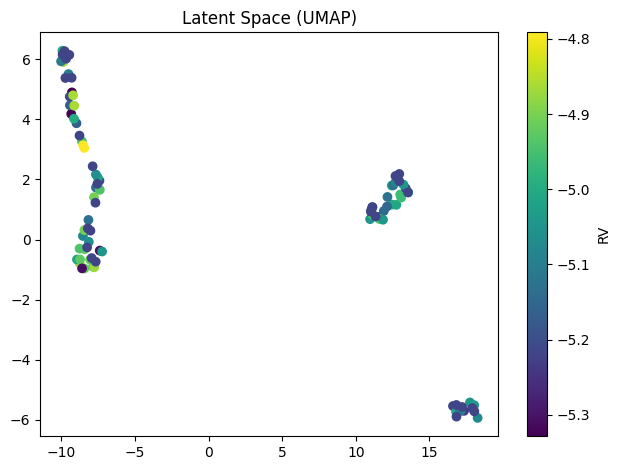

In [23]:
plt.scatter(latent_umap[:, 0], latent_umap[:, 1], c=meta["RV"], cmap="viridis")
plt.colorbar(label="RV")
plt.title("Latent Space (UMAP)")
plt.tight_layout()
save_path = f"outputs/models/vae_base/v_{MODEL_VERSION}/plots/UMAP/SNR_RV.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()

### 6. Reproduced Lines

**Reconstructions from the VAE:**

In [24]:
x_reconstructed = scaler.inverse_transform(x_pred)
x_input_original = scaler.inverse_transform(X_scaled)

**Spectra with vertical activity lines**

In [25]:
i = 10

For the first Spectrum:

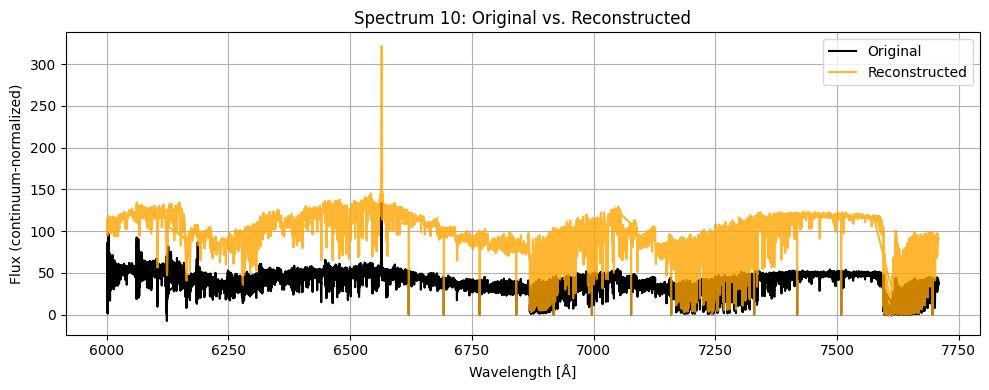

In [30]:
with fits.open(vis_a_files[0]) as hdul:
    wave_data = hdul["WAVE"].data  # shape: (n_orders, n_pixels)

# Stack the wavelengths for VALID_ORDERS just like the flux
wavelengths_stacked = np.hstack([wave_data[o] for o in VALID_ORDERS])  # shape: (n_orders × n_pixels)

# Now plot using wavelength on the x-axis
plt.figure(figsize=(10, 4))
plt.plot(wavelengths_stacked, x_input_original[i], label="Original", color="black")
plt.plot(wavelengths_stacked, x_reconstructed[i], label="Reconstructed", color="orange", linestyle="-", alpha=0.8)
plt.title(f"Spectrum {i}: Original vs. Reconstructed")
plt.xlabel("Wavelength [Å]")
plt.ylabel("Flux (continuum-normalized)")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_path = f"outputs/models/vae_base/v_{MODEL_VERSION}/plots/reconstruction/full_spec.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()

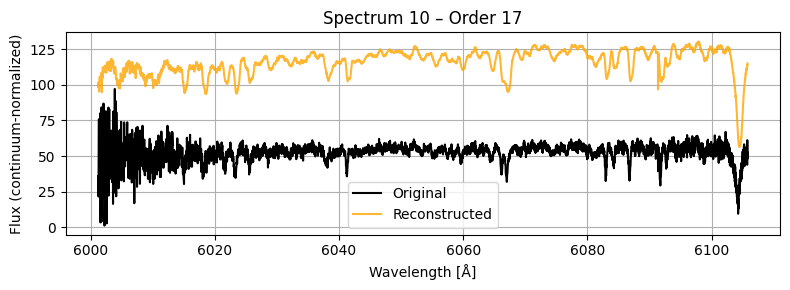

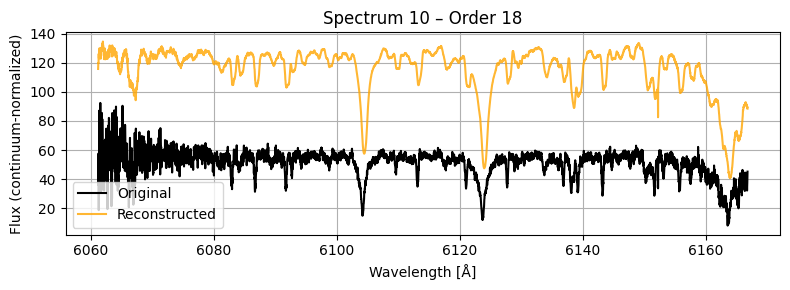

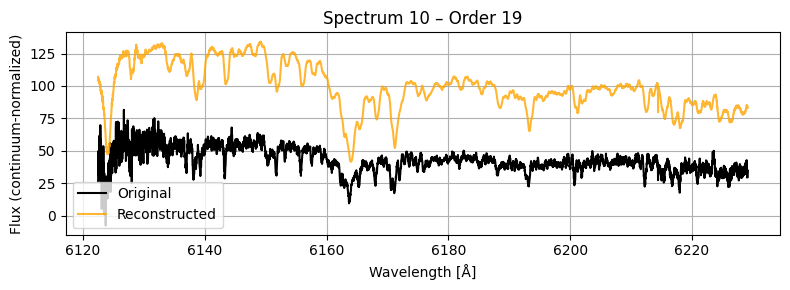

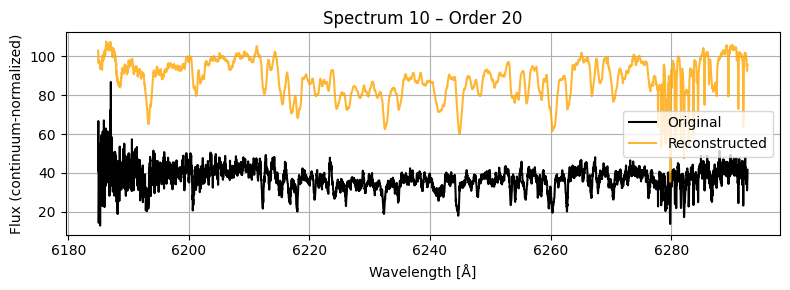

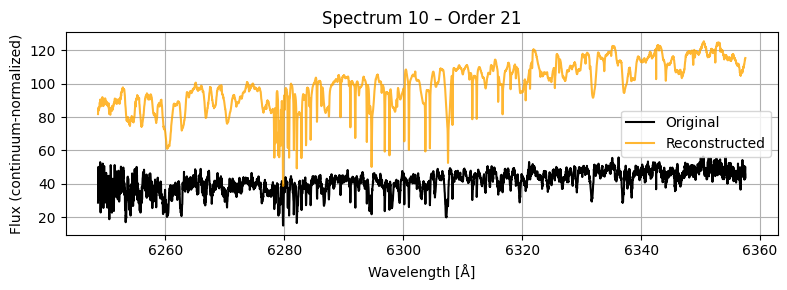

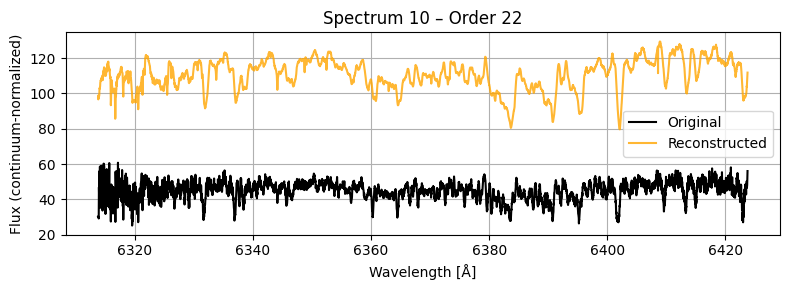

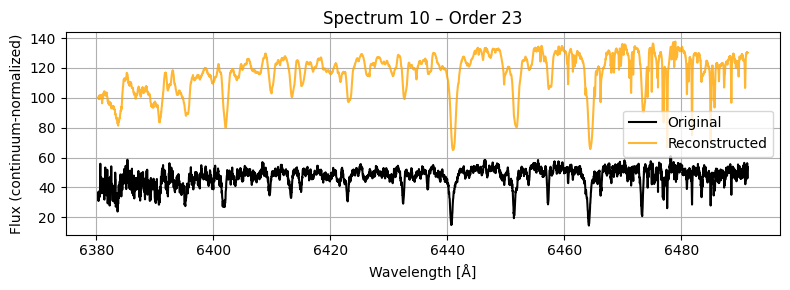

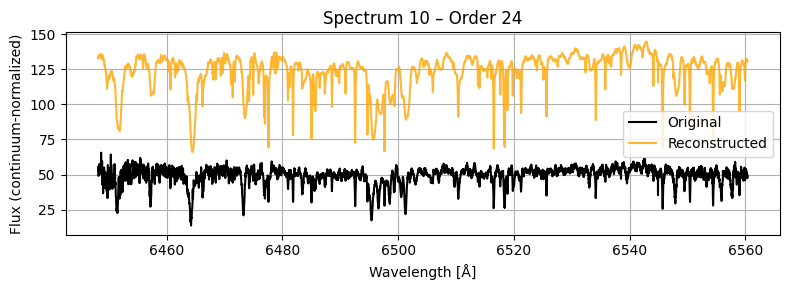

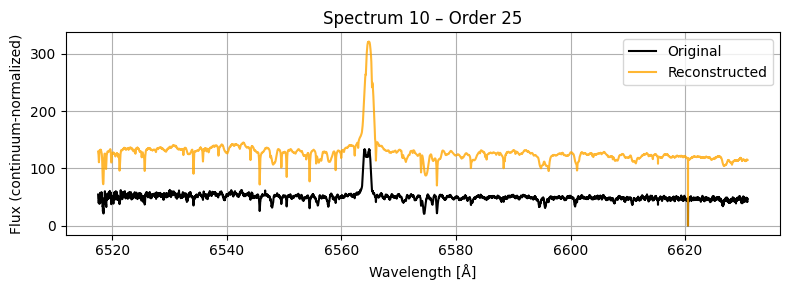

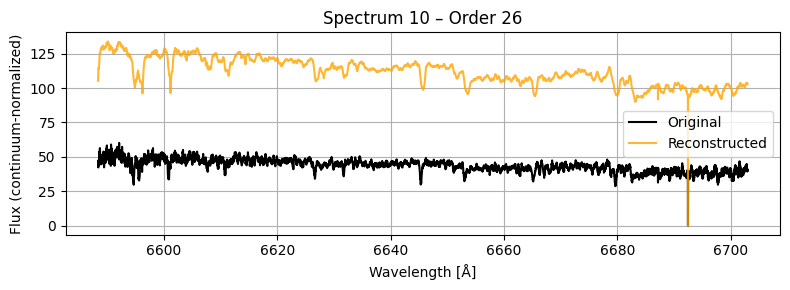

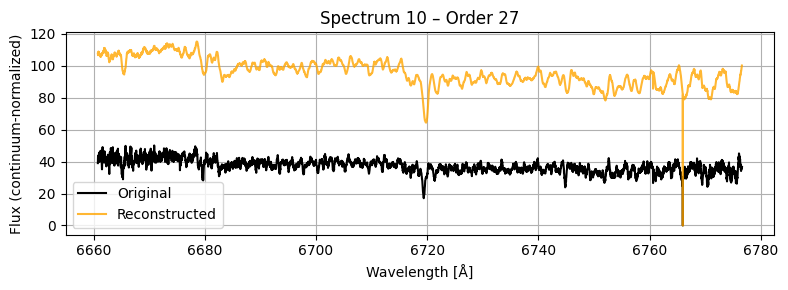

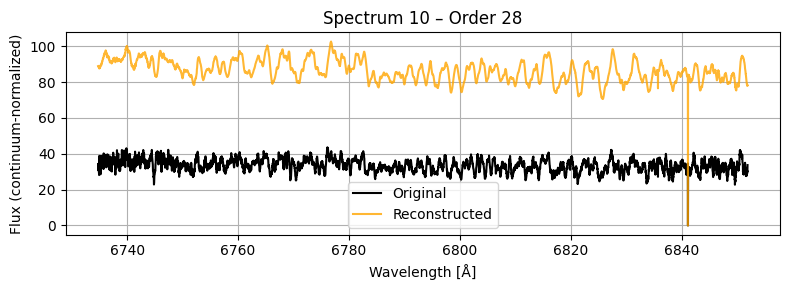

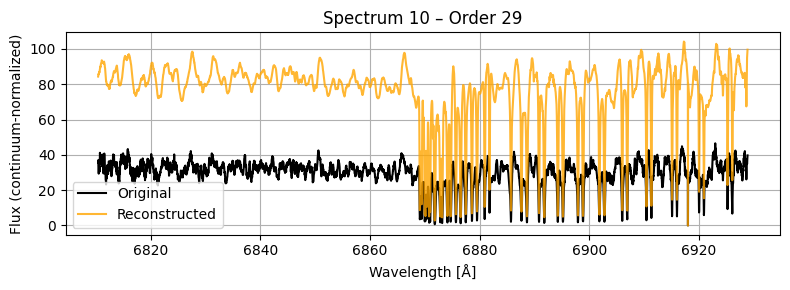

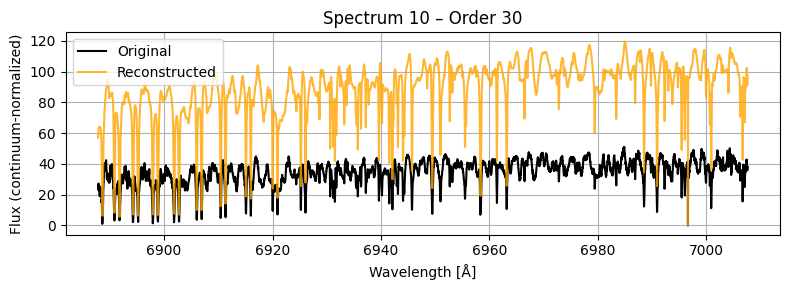

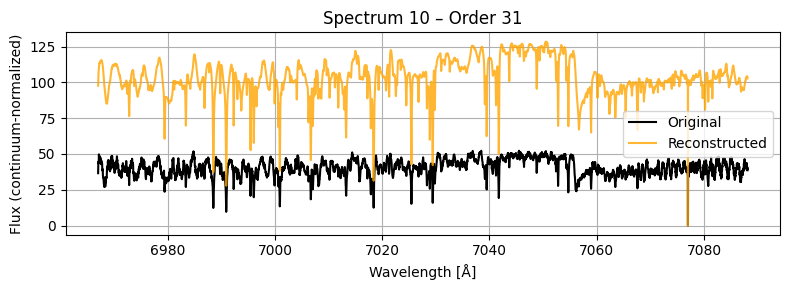

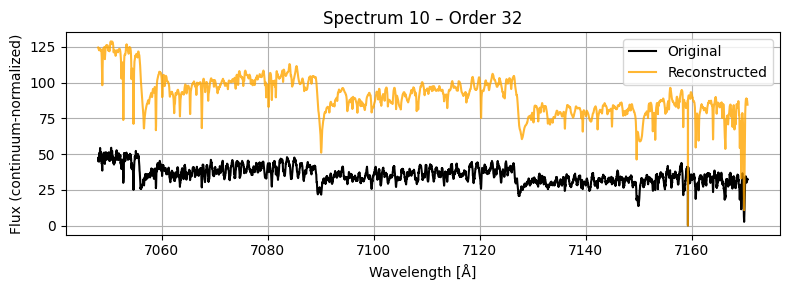

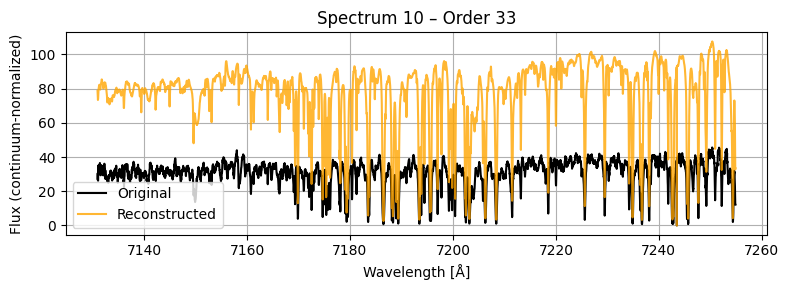

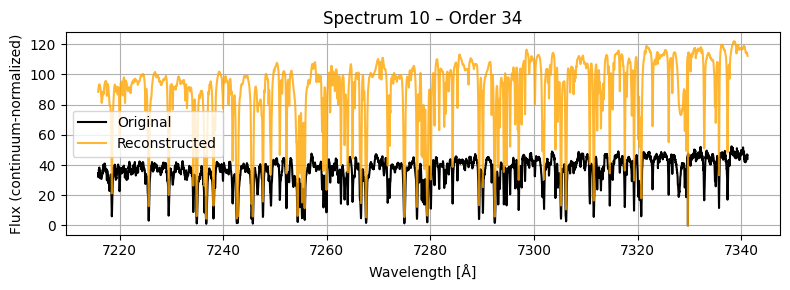

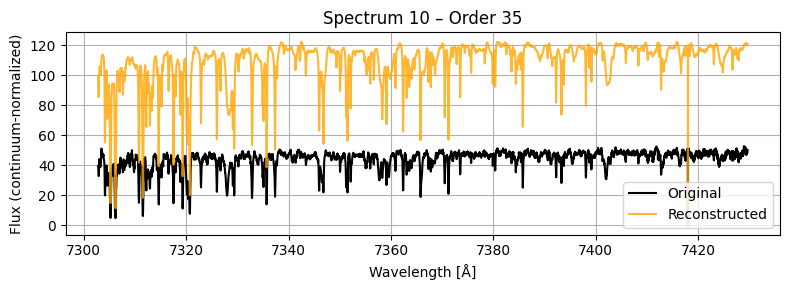

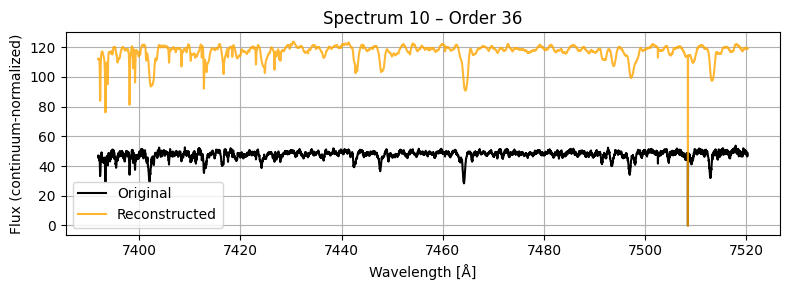

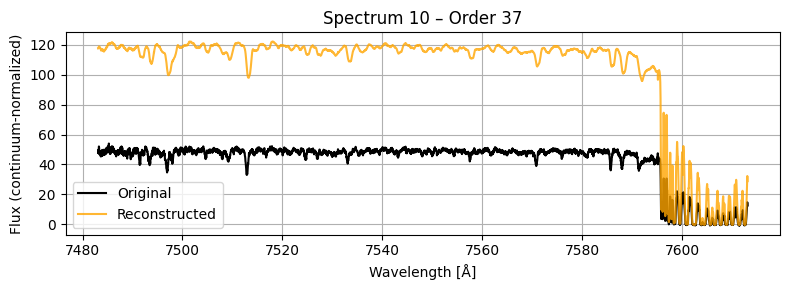

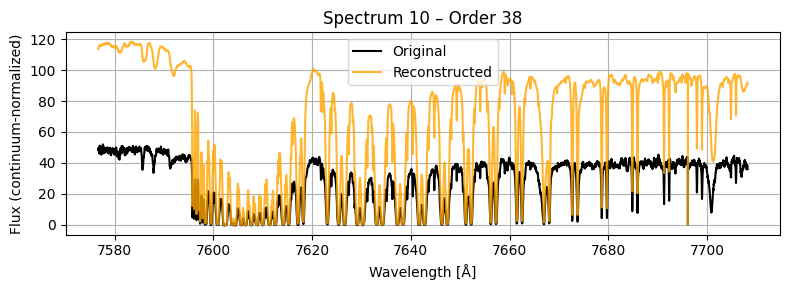

In [31]:
pixels_per_order = wave_data.shape[1]  # usually 2048
n_orders = len(VALID_ORDERS)

for j, order in enumerate(VALID_ORDERS):
    start = j * pixels_per_order
    end = start + pixels_per_order

    wavelength = wave_data[order]
    original_flux = x_input_original[i, start:end]
    reconstructed_flux = x_reconstructed[i, start:end]

    plt.figure(figsize=(8, 3))
    plt.plot(wavelength, original_flux, label="Original", color="black")
    plt.plot(wavelength, reconstructed_flux, label="Reconstructed", color="orange", linestyle="-", alpha=0.8)
    plt.title(f"Spectrum {i} – Order {order}")
    plt.xlabel("Wavelength [Å]")
    plt.ylabel("Flux (continuum-normalized)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    save_path = f"outputs/models/vae_base/v_{MODEL_VERSION}/plots/reconstruction/by_order/order_{order}.png"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()

### 7. Lomb-Scargle Periodograms

Latent dim 0: Best period = 4.446 days


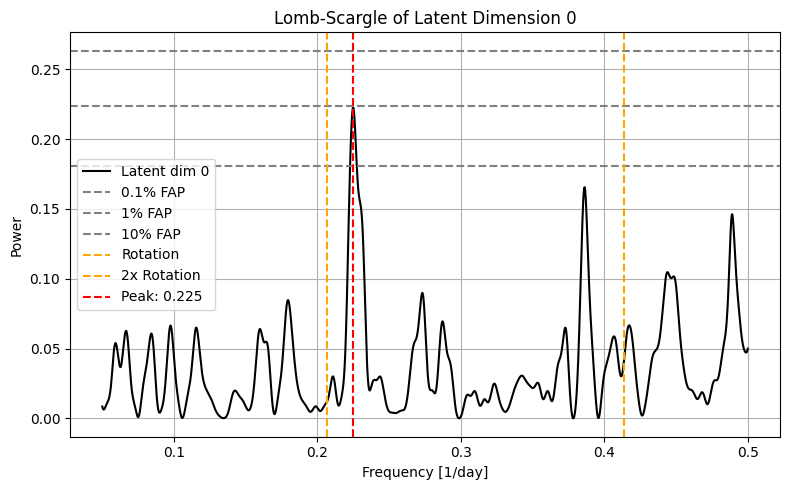

Latent dim 1: Best period = 4.446 days


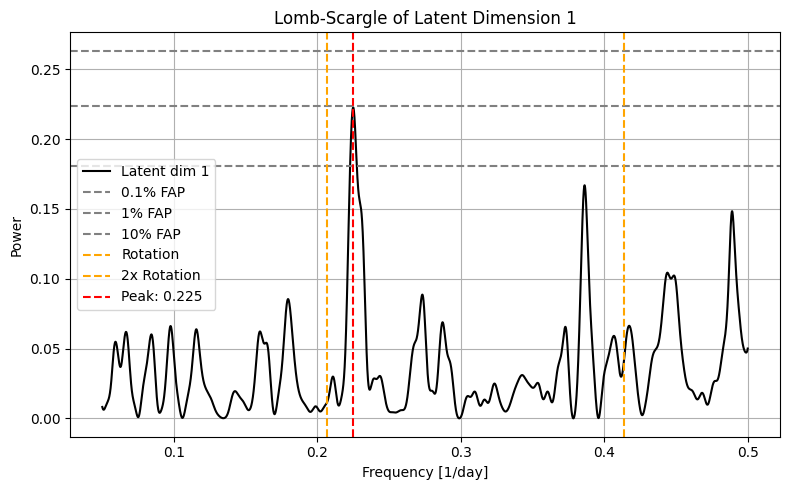

Latent dim 2: Best period = 4.448 days


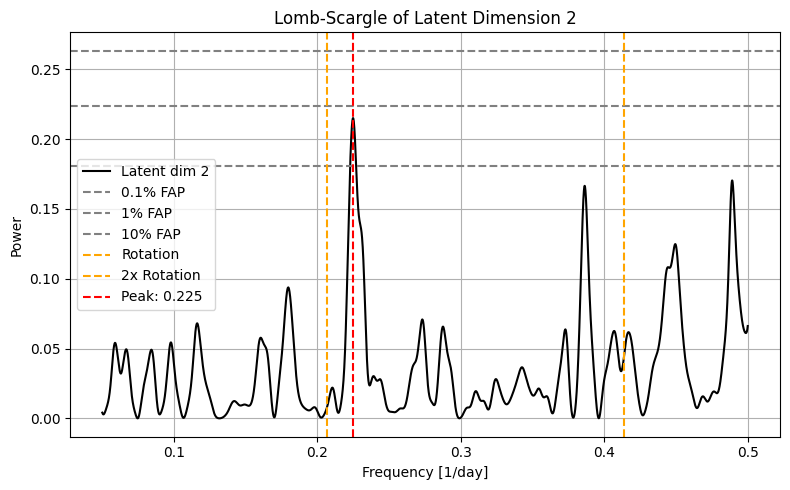

Latent dim 3: Best period = 4.446 days


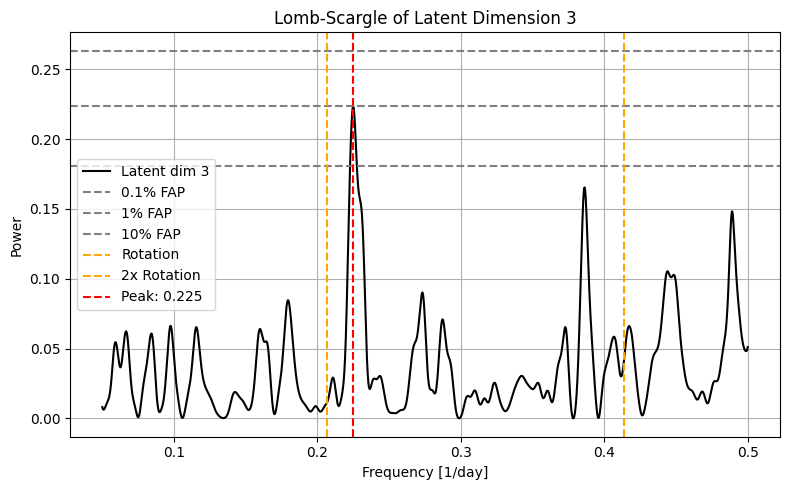

Latent dim 4: Best period = 4.446 days


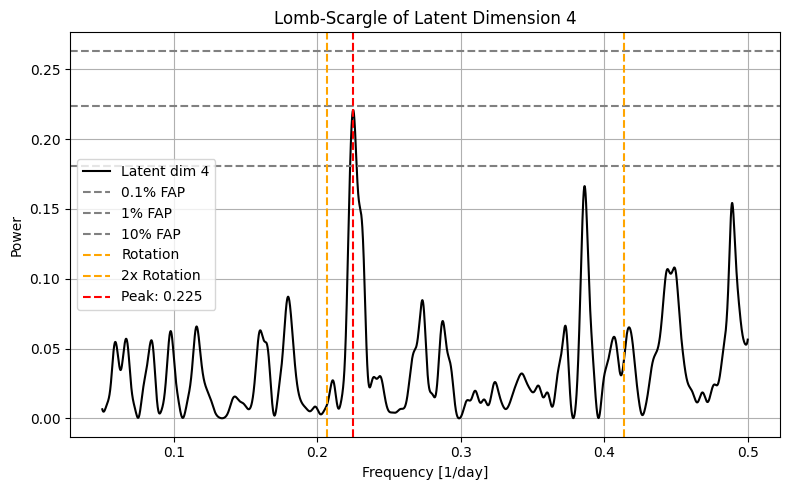

Latent dim 5: Best period = 4.450 days


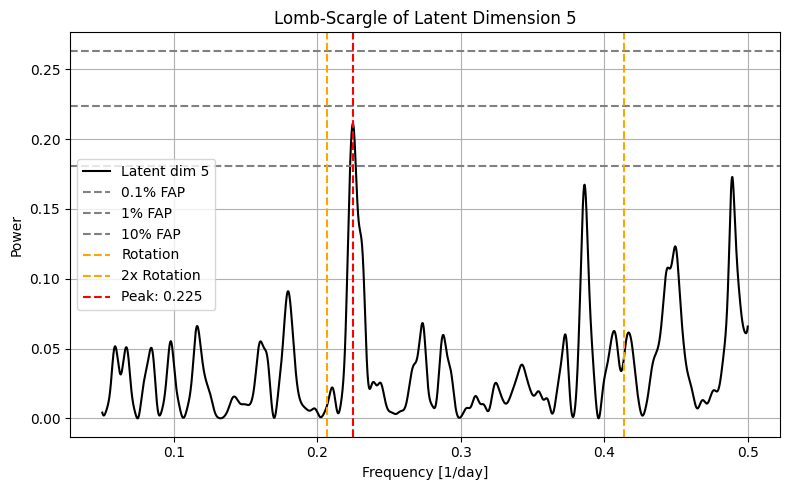

Latent dim 6: Best period = 4.448 days


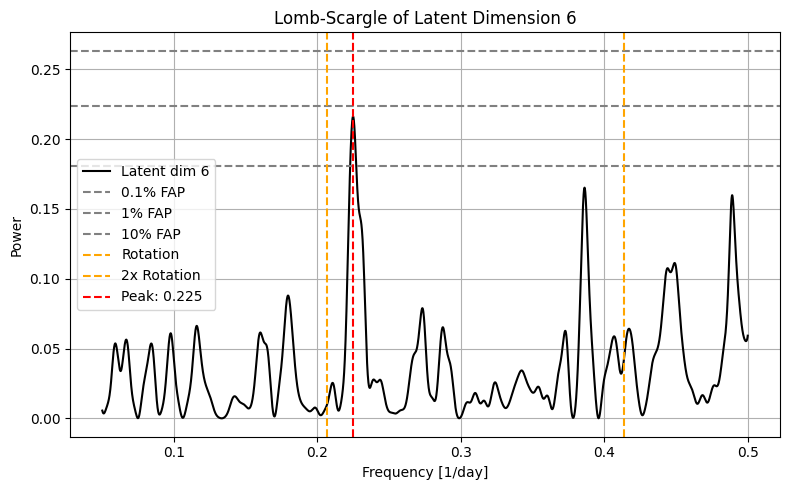

Latent dim 7: Best period = 4.445 days


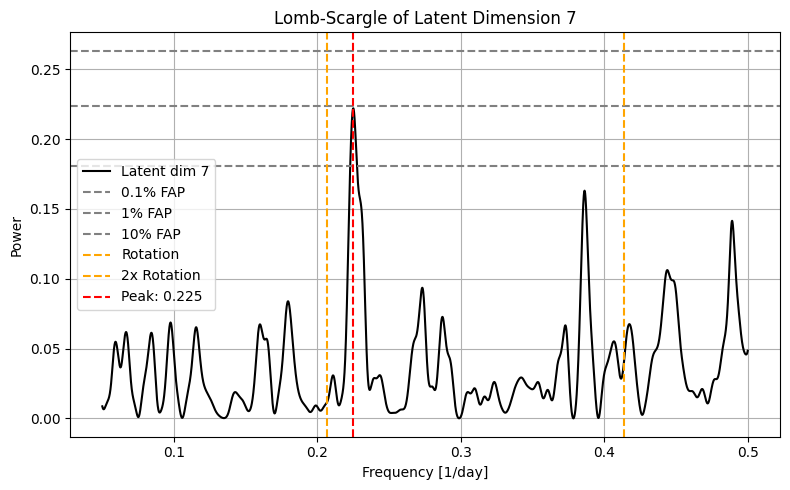

In [32]:
time = meta["BJD"].values
frequencies = np.linspace(1/20, 0.5, 5000)
rotation_period = 4.8367
rotation_freq = 1 / rotation_period

for i in range(z_mean.shape[1]):
    y = z_mean[:, i] - np.mean(z_mean[:, i])
    ls = LombScargle(time, y)
    power = ls.power(frequencies)
    fap_01 = ls.false_alarm_level(0.001)
    fap_1 = ls.false_alarm_level(0.01)
    fap_10 = ls.false_alarm_level(0.1)
    best_freq = frequencies[np.argmax(power)]
    best_period = 1 / best_freq

    plt.figure(figsize=(8, 5))
    plt.plot(frequencies, power, label=f"Latent dim {i}", color='black')
    plt.axhline(fap_01, linestyle='--', color='gray', label='0.1% FAP')
    plt.axhline(fap_1, linestyle='--', color='gray', label='1% FAP')
    plt.axhline(fap_10, linestyle='--', color='gray', label='10% FAP')
    plt.axvline(rotation_freq, color='orange', linestyle='--', label='Rotation')
    plt.axvline(2 * rotation_freq, color='orange', linestyle='--', label='2x Rotation')
    plt.axvline(best_freq, color='red', linestyle='--', label=f'Peak: {best_freq:.3f}')
    plt.xlabel("Frequency [1/day]")
    plt.ylabel("Power")
    plt.title(f"Lomb-Scargle of Latent Dimension {i}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    print(f"Latent dim {i}: Best period = {best_period:.3f} days")
    save_path = f"outputs/models/vae_base/v_{MODEL_VERSION}/plots/lomb_scargle/dimension_{i}.png"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()

### 7. Save Model

Also saving the configuration:

In [33]:
settings = {
    "input_dim": int(X.shape[1]),
    "latent_dim": int(LATENT_DIM),
    "activation": str(ACTFN),
    "dropout": float(DROPOUT),
    "learning_rate": float(LEARNING_RATE),
    "beta_variable": float(BETA_VAR.numpy().item()), 
    "beta_max": float(BETA_MAX),
    "batch_size": int(BATCH_SIZE),
    "epochs": int(EPOCHS),
    "valid_orders": [int(o) for o in VALID_ORDERS],  
}

In [34]:
def save_all_models(vae, encoder, decoder, path_prefix):
    os.makedirs(os.path.dirname(path_prefix), exist_ok=True)
    vae.save(f"{path_prefix}fullmodel.keras")
    encoder.save(f"{path_prefix}encoder.keras")
    decoder.save(f"{path_prefix}decoder.keras")
    with open(f"{path_prefix}config.json", "w") as f:
        json.dump(settings, f, indent=2)
    print(f"Models saved to {path_prefix}_*.keras")

In [35]:
save_all_models(vae, encoder, decoder, f"outputs/models/vae_base/v_{MODEL_VERSION}/")

Models saved to outputs/models/vae_base/v_0/_*.keras
